# Hovmoller FWC and Sea Ice Volume distribution

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40747")
client

<Client: 'tcp://127.0.0.1:40747' processes=8 threads=32, memory=123.95 GiB>

**PROCEDURE:**

1. Select days after sea ice minimum each year.
2. Mask grid cells where SIC>15% at minimum.
3. Calculate FWC in each grid cell, then bin grid cells (100 bins).
4. For each FWC bin and timestep, compute mean sea ice volume.

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open HEFF zarr store
heff_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIheff_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

In [7]:
# The volume of ice in a grid cell is = HEFF * grid cell area
ice_vol_beaufort = heff_da.SIheff.isel(i=slice(450,750),j=slice(110,390)) * HH_grid.rAc.isel(i=slice(450,750),j=slice(110,390))

In [8]:
# carve out beaufort region
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [9]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [10]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [11]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [12]:
# select days after sea ice minimum for SIC, SI vol, and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
ice_vol_yrs = ice_vol_beaufort.sel(time=full_date_array)
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,7)) # only upper 10 m

In [13]:
# look at depth of grid cell center and bottom of grid cell
print(salt_yrs.Z.values)
print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

[-0.5   -1.57  -2.79  -4.185 -5.78  -7.595 -9.66 ]
[ -1.    -2.14  -3.44  -4.93  -6.63  -8.56 -10.76]


In [14]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

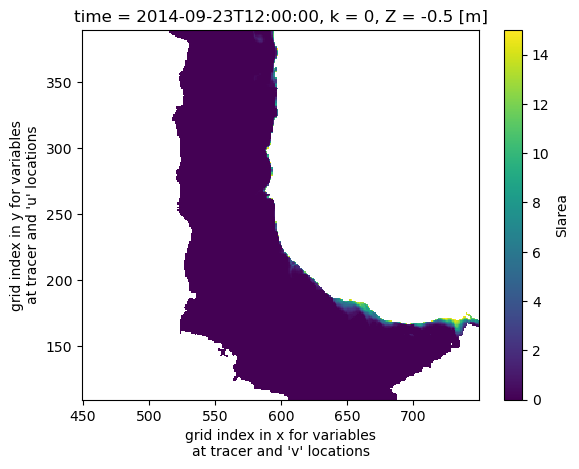

In [15]:
ice_yrs_masked.sel(time='2014').isel(time=0).plot();

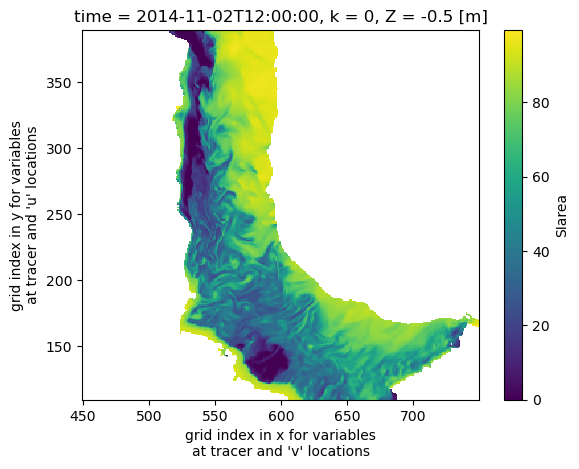

In [16]:
ice_yrs_masked.sel(time='2014').isel(time=40).plot();

## 2. Calculate FWC and bin data into 100 bins

In [17]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [18]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [19]:
# mask land grid cells and where SIC>15% on ice minimum date
ice_vol_yrs_masked = ice_vol_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

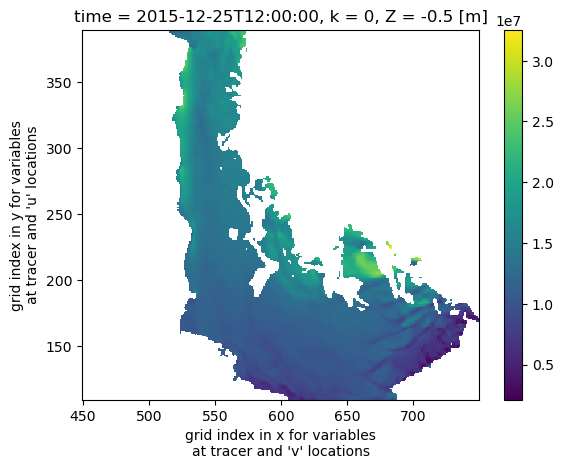

In [20]:
# sanity check
ice_vol_yrs_masked.isel(time=200).plot();

In [21]:
# determine the upper end of the dataset
fwc_yrs_masked.max().values

array(6.75552669)

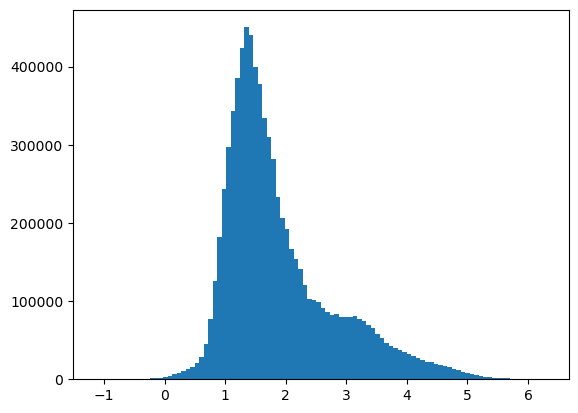

In [22]:
# look at histogram of FWC for a few years
plt.hist(np.ravel(fwc_yrs_masked.sel(time=slice('2014','2016')).values),100);

In [23]:
# define FWC bins
fwc_bins = np.linspace(0,5,99)
fwc_bins = np.append(fwc_bins, 7) # total of 100, the last bin is all FWC values between 5 and 7 m

In [24]:
len(fwc_bins)

100

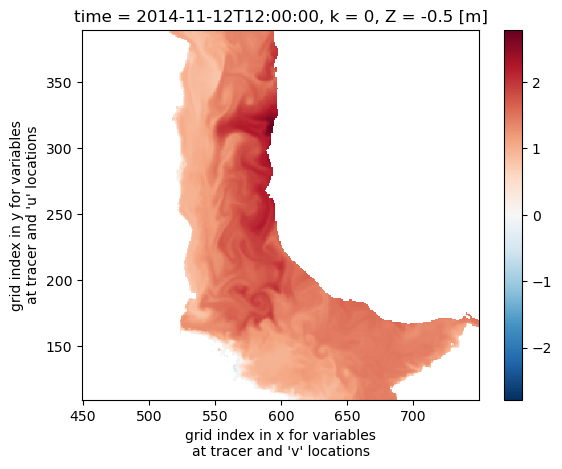

In [25]:
fwc_yrs_masked.isel(time=50).plot();

In [26]:
# bin each grid cell into FWC intervals
# use np.digitize to bin the values according to fwc_bins
fwc_binned_yrs = np.digitize(fwc_yrs_masked, fwc_bins, right=False)

In [27]:
fwc_binned_yrs.shape

(733, 280, 300)

In [28]:
# sanity check
print(fwc_binned_yrs[0,110,145]) # index = 75
print(fwc_bins[75]) # index provides the upper end of the bin interval
print(fwc_bins[74:76]) # upper and lower ends of the bin
print(fwc_yrs_masked.values[0,110,145]) # actual value from this grid cell, and it falls within the bin range - looks good!

75
3.826530612244898
[3.7755102  3.82653061]
3.824052925438716


In [29]:
fwc_binned_da = xr.DataArray(data = fwc_binned_yrs, dims=['time', 'j', 'i'],\
                             coords={'time': fwc_yrs_masked.time.values, 'j': fwc_yrs_masked.j.values, 'i': fwc_yrs_masked.i.values})

In [30]:
# mask out land and sea ice
fwc_binned_da = fwc_binned_da.where(land_sic_mask_yr)

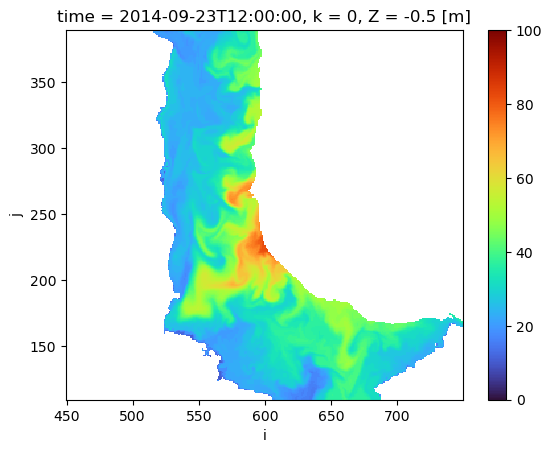

In [31]:
fwc_binned_da.isel(time=0).plot(vmin=0,vmax=100,cmap='turbo');

In [32]:
# figure out what bin index is FWC of 2m or more
x_tick_index = np.argmin(abs(fwc_bins - 2))
print(x_tick_index)

39


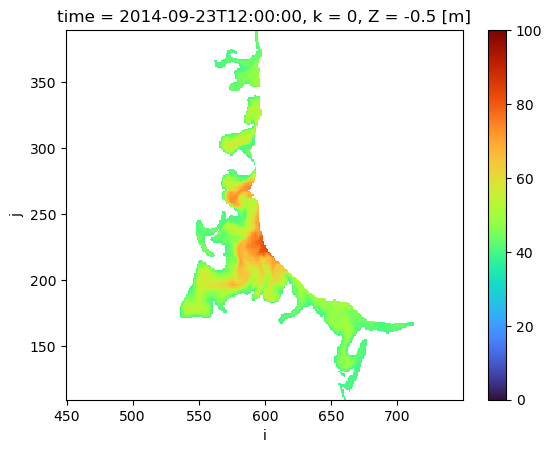

In [33]:
# fwc_binned_da.isel(time=0).where((fwc_binned_da.isel(time=0)>39) & (fwc_binned_da.isel(time=0)<90)).plot(vmin=0,vmax=100,cmap='turbo');
fwc_binned_da.isel(time=0).where(fwc_binned_da.isel(time=0)>39).plot(vmin=0,vmax=100,cmap='turbo');

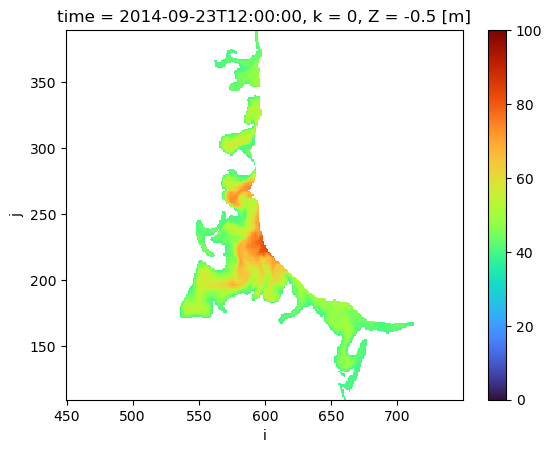

In [34]:
# calculate average fwc over whole region for each month

fwc_binned_da.isel(time=0).where(fwc_binned_da.isel(time=0)>39).plot(vmin=0,vmax=100,cmap='turbo');

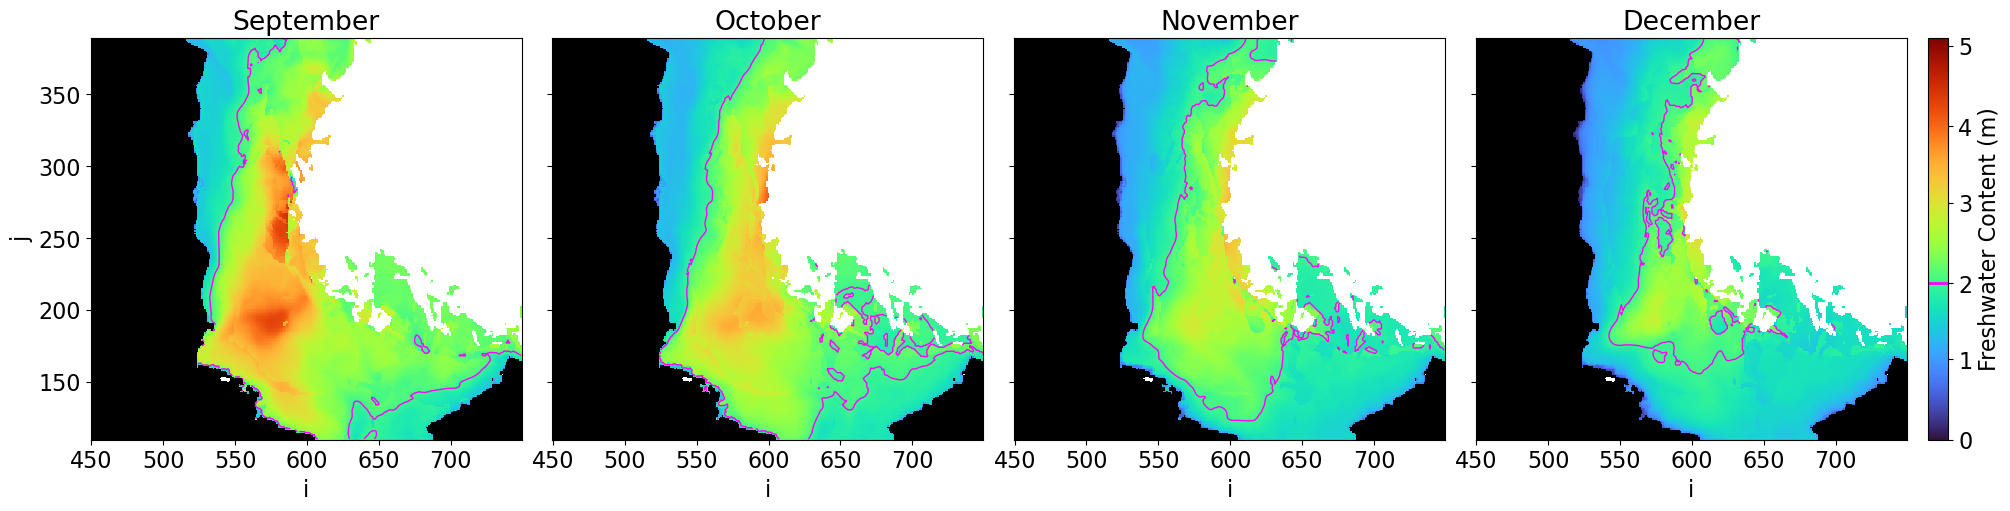

In [35]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, figsize=(20, 5), layout='constrained')

x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)), \
                  np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)), np.argmin(abs(fwc_bins - 5))]

tick_labels = ['0', '1', '2', '3', '4', '5']

for i, (month, ax) in enumerate(zip(months, axes)):
    # plot land
    HH_grid_land.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)
    # plot FWC
    monthly_mean = fwc_binned_da.sel(time=fwc_binned_da['time.month'] == month).mean(dim='time')
    cbar_fwc = monthly_mean.plot(ax=ax, vmin=0, vmax=100, cmap='turbo', add_colorbar=False)
    # add contour line for FWC==2
    monthly_mean.plot.contour(ax=ax, levels=[np.argmin(abs(fwc_bins - 2))], colors='magenta', linewidths=1, add_colorbar=False)
    ax.set_title(month_names[i])
    ax.set_ylabel("")

axes[0].set_ylabel("j")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_fwc, ax=ax, orientation='vertical', pad=0.05, ticks=x_tick_indices)
cbar.ax.set_ylabel('Freshwater Content (m)')
cbar.set_ticklabels(tick_labels)
cbar.ax.axhline(y=x_tick_indices[2], color='magenta', linewidth=2)

plt.show()

In [31]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 3D xarray.DataArray (time, i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('i', 'j').
    """
    rotated = np.rot90(da,3,axes=[0,1])
    
    out = xr.DataArray(
        data=rotated,
        dims=('i','j'),
        coords={
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [45]:
# Rotate the fields so that alaska is on the bottom
monthly_mean_rot = rotate_dataarray_90ccw(monthly_mean)

From raw FWC data

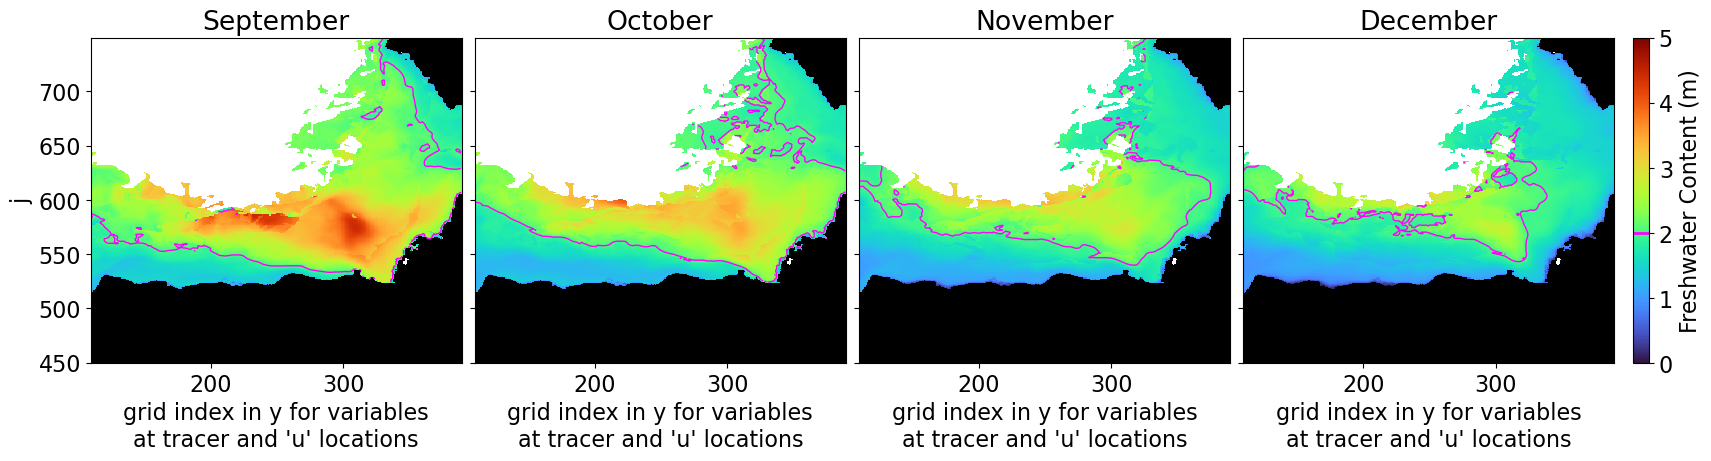

In [39]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, figsize=(17, 4.5), layout='constrained')

x_tick_indices = np.arange(0,6,1)
tick_labels = ['0', '1', '2', '3', '4', '5']

for i, (month, ax) in enumerate(zip(months, axes)):
    # plot land
    HH_grid_land_rot = rotate_dataarray_90ccw(HH_land_beaufort)
    HH_grid_land_rot.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)
    
    # plot FWC
    monthly_mean = fwc_yrs_masked.sel(time=fwc_yrs_masked['time.month'] == month).mean(dim='time')
    monthly_mean_rot = rotate_dataarray_90ccw(monthly_mean)
    cbar_fwc = monthly_mean_rot.plot(ax=ax, vmin=0, vmax=5, cmap='turbo', add_colorbar=False)
    
    # add contour line for FWC==2
    monthly_mean_rot.plot.contour(ax=ax, levels=[2], colors='magenta', linewidths=1, add_colorbar=False)
    ax.set_title(month_names[i])
    ax.set_ylabel("")

axes[0].set_ylabel("j")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_fwc, ax=ax, orientation='vertical', pad=0.05, ticks=x_tick_indices)
cbar.ax.set_ylabel('Freshwater Content (m)')
cbar.set_ticklabels(tick_labels)
cbar.ax.axhline(y=2, color='magenta', linewidth=2)

plt.show()

From binned FWC data

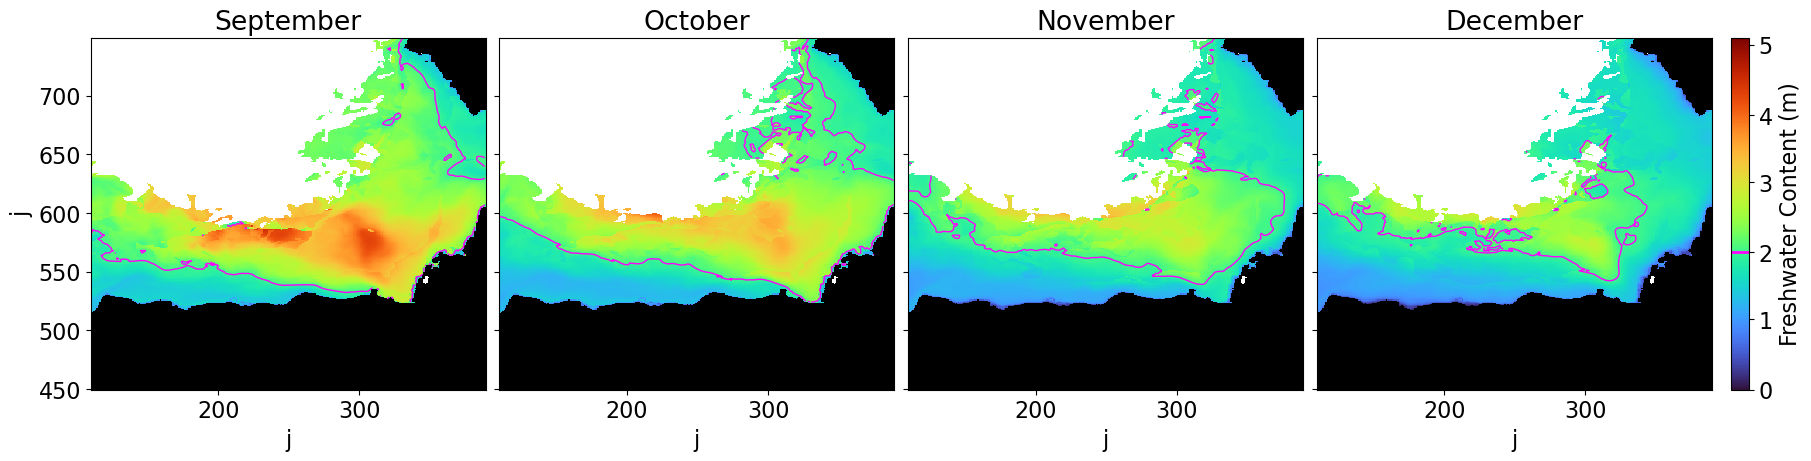

In [51]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, figsize=(18, 4.5), layout='constrained')

x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)), \
                  np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)), np.argmin(abs(fwc_bins - 5))]

tick_labels = ['0', '1', '2', '3', '4', '5']

for i, (month, ax) in enumerate(zip(months, axes)):
    # plot land
    HH_grid_land_rot = rotate_dataarray_90ccw(HH_land_beaufort)
    HH_grid_land_rot.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)
    
    # plot FWC
    monthly_mean = fwc_binned_da.sel(time=fwc_binned_da['time.month'] == month).mean(dim='time')
    monthly_mean_rot = rotate_dataarray_90ccw(monthly_mean)
    cbar_fwc = monthly_mean_rot.plot(ax=ax, vmin=0, vmax=100, cmap='turbo', add_colorbar=False)
    
    # add contour line for FWC==2
    monthly_mean_rot.plot.contour(ax=ax, levels=[np.argmin(abs(fwc_bins - 2))], colors='magenta', linewidths=1, add_colorbar=False)
    ax.set_title(month_names[i])
    ax.set_ylabel("")

axes[0].set_ylabel("j")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_fwc, ax=ax, orientation='vertical', pad=0.05, ticks=x_tick_indices)
cbar.ax.set_ylabel('Freshwater Content (m)')
cbar.set_ticklabels(tick_labels)
cbar.ax.axhline(y=x_tick_indices[2], color='magenta', linewidth=2)

plt.show()

Mean SIC

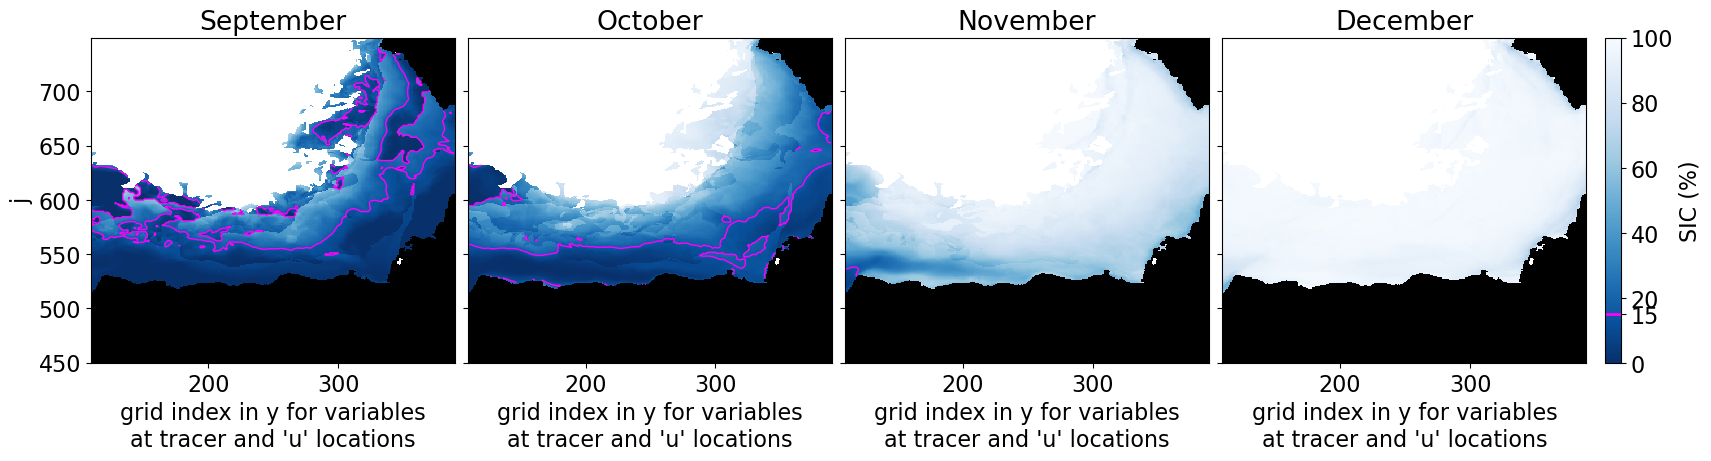

In [41]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, figsize=(17, 4.5), layout='constrained')

x_tick_indices = [0,15,20,40,60,80,100]
tick_labels = ['0', '15', '20', '40', '60', '80', '100']

for i, (month, ax) in enumerate(zip(months, axes)):
    # plot land
    HH_grid_land_rot = rotate_dataarray_90ccw(HH_land_beaufort)
    HH_grid_land_rot.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)
    
    # plot FWC
    monthly_mean = ice_yrs_masked.sel(time=ice_yrs_masked['time.month'] == month).mean(dim='time')
    monthly_mean_rot = rotate_dataarray_90ccw(monthly_mean)
    cbar_fwc = monthly_mean_rot.plot(ax=ax, vmin=0, vmax=100, cmap='Blues_r', add_colorbar=False)
    
    # add contour line for FWC==2
    monthly_mean_rot.plot.contour(ax=ax, levels=[15], colors='magenta', linewidths=1, add_colorbar=False)
    ax.set_title(month_names[i])
    ax.set_ylabel("")

axes[0].set_ylabel("j")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_fwc, ax=ax, orientation='vertical', pad=0.05, ticks=x_tick_indices)
cbar.ax.set_ylabel('SIC (%)')
cbar.set_ticklabels(tick_labels)
cbar.ax.axhline(y=15, color='magenta', linewidth=2)

plt.show()

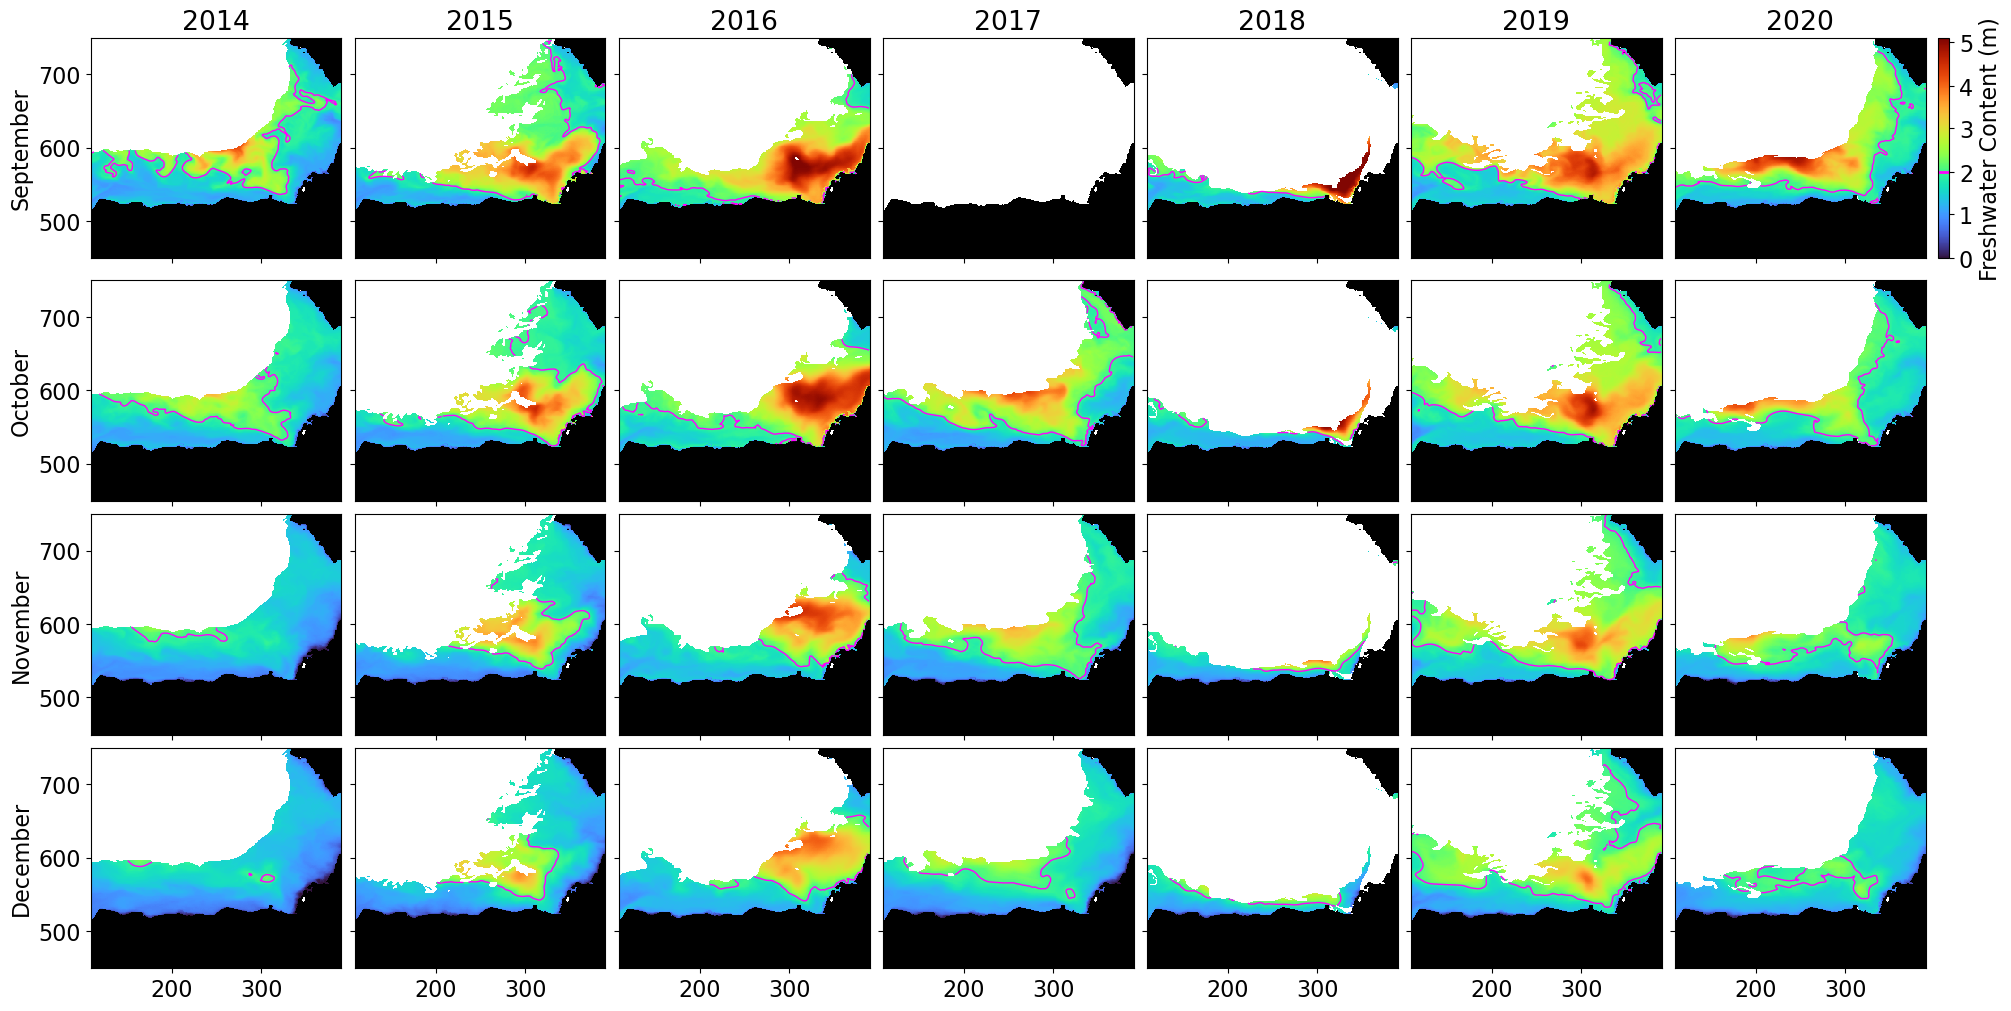

In [54]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']
years = list(range(2014, 2021))  # 2014–2020

fig, axes = plt.subplots(nrows=len(months), ncols=len(years), sharex=True, sharey=True, figsize=(20, 10), layout='constrained')

x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)), \
                  np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)), np.argmin(abs(fwc_bins - 5))]

tick_labels = ['0', '1', '2', '3', '4', '5']

for month_idx, month in enumerate(months):
    for year_idx, year in enumerate(years):
        ax = axes[month_idx, year_idx]

        # plot land
        HH_grid_land_rot = rotate_dataarray_90ccw(HH_land_beaufort)
        HH_grid_land_rot.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)

        # Select data for specific year and month
        monthly_data = fwc_binned_da.sel(
            time=(fwc_binned_da['time.year'] == year) & 
                 (fwc_binned_da['time.month'] == month)
        ).mean(dim='time')
        
        # Plot FWC
        monthly_data_rot = rotate_dataarray_90ccw(monthly_data)
        plot_obj = monthly_data_rot.plot(ax=ax, vmin=0, vmax=100, cmap='turbo', add_colorbar=False)
        
        # add contour line for FWC==2
        monthly_data_rot.plot.contour(ax=ax, levels=[np.argmin(abs(fwc_bins - 2))], colors='magenta', linewidths=1, add_colorbar=False)
        
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title("")
        
        # Titles and labels
        if month_idx == 0:
            ax.set_title(str(year))
        if year_idx == 0:
            ax.set_ylabel(month_names[month_idx])

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_fwc, ax=axes[0, 6], orientation='vertical', pad=0.05, ticks=x_tick_indices)
cbar.ax.set_ylabel('Freshwater Content (m)')
cbar.set_ticklabels(tick_labels)
cbar.ax.axhline(y=x_tick_indices[2], color='magenta', linewidth=2)

plt.show()

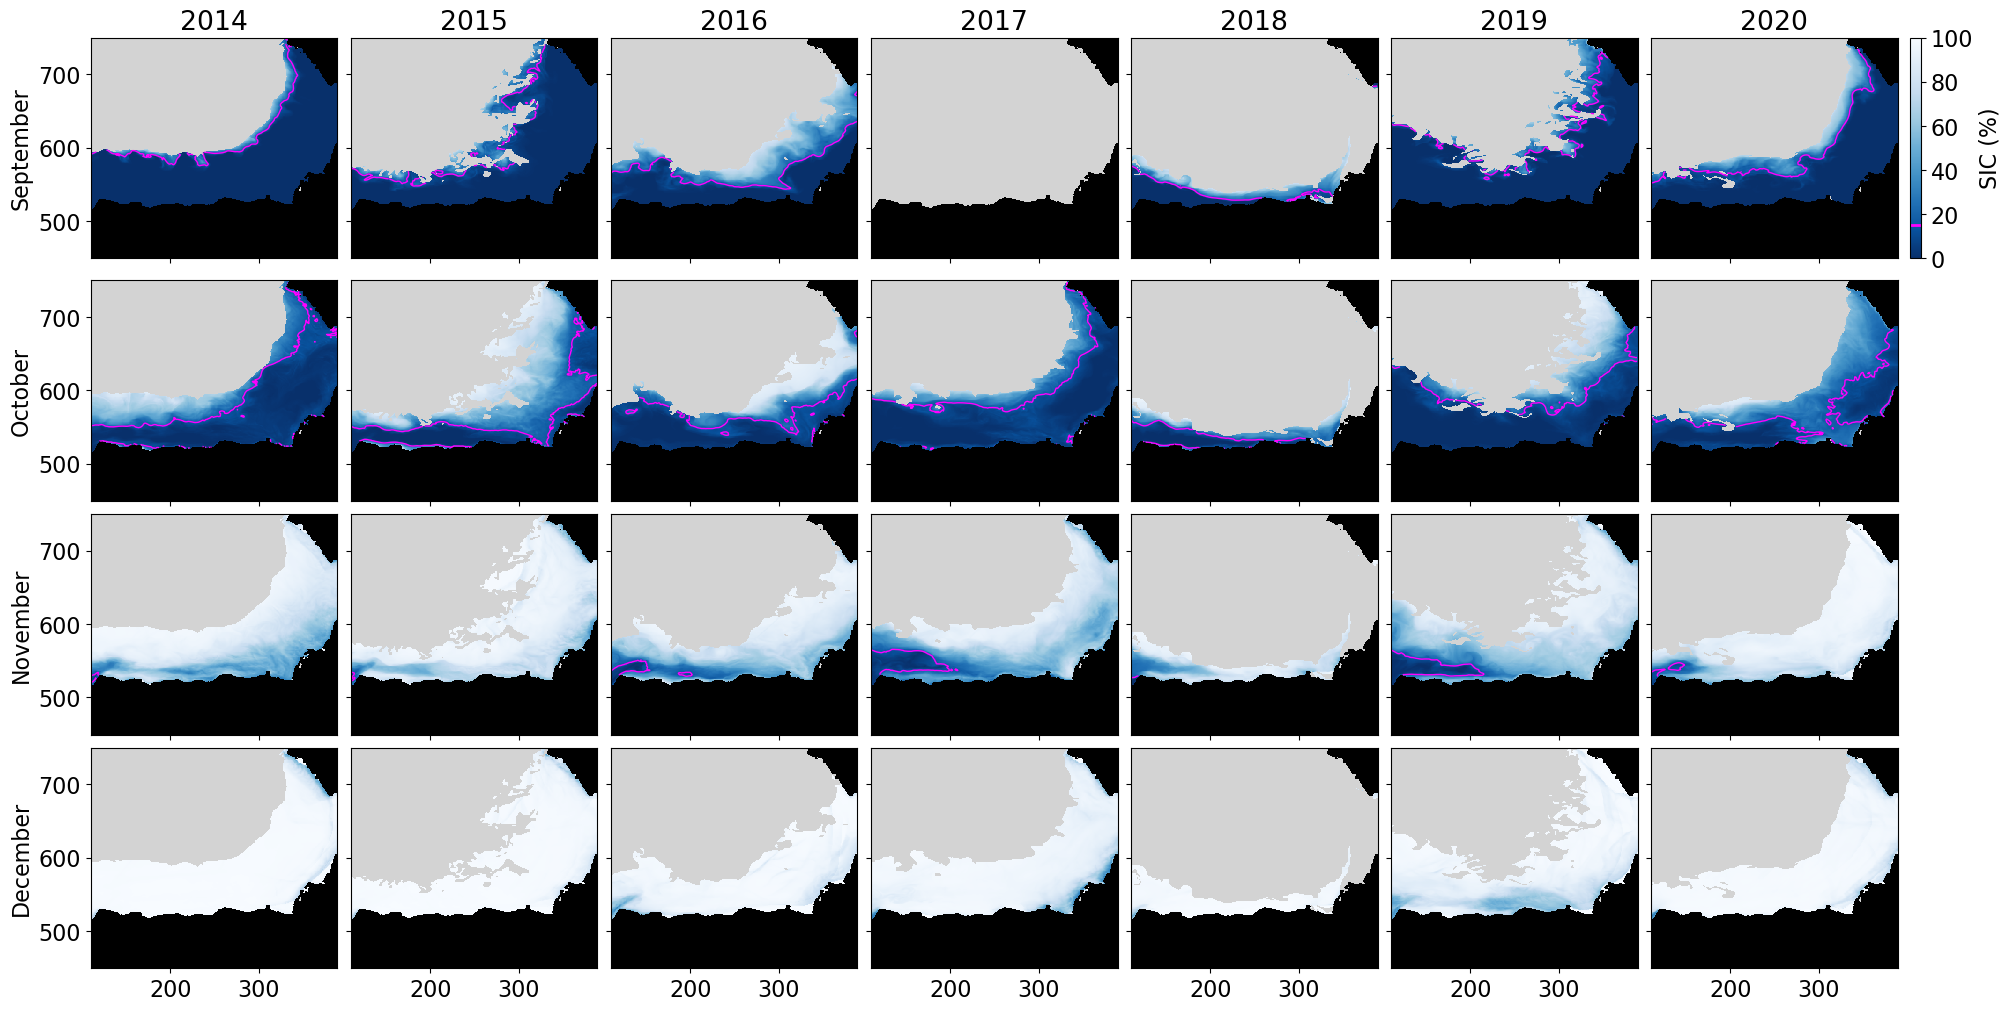

In [56]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']
years = list(range(2014, 2021))  # 2014–2020

fig, axes = plt.subplots(nrows=len(months), ncols=len(years), sharex=True, sharey=True, figsize=(20, 10), layout='constrained')

for month_idx, month in enumerate(months):
    for year_idx, year in enumerate(years):
        ax = axes[month_idx, year_idx]

        # plot land
        HH_grid_land_rot = rotate_dataarray_90ccw(HH_land_beaufort)
        HH_grid_land_rot.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)
        
        ax.set_facecolor('lightgray')
        
        # Select data for specific year and month
        monthly_data = ice_yrs_masked.sel(
            time=(ice_yrs_masked['time.year'] == year) & 
                 (ice_yrs_masked['time.month'] == month)
        ).mean(dim='time')
        
        # Plot sea ice conc
        monthly_data_rot = rotate_dataarray_90ccw(monthly_data)
        plot_obj = monthly_data_rot.plot(ax=ax, vmin=0, vmax=100, cmap='Blues_r', add_colorbar=False)
        
        # add contour line for SIC=15%
        monthly_data_rot.plot.contour(ax=ax, levels=[15], colors='magenta', linewidths=1, add_colorbar=False)
        
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title("")
        
        # Titles and labels
        if month_idx == 0:
            ax.set_title(str(year))
        if year_idx == 0:
            ax.set_ylabel(month_names[month_idx])

# Add colorbar to the last axis
cbar = fig.colorbar(plot_obj, ax=axes[0, 6], orientation='vertical', pad=0.05, ticks=[0,20,40,60,80,100])
cbar.ax.set_ylabel('SIC (%)')
cbar.ax.axhline(y=15, color='magenta', linewidth=2)

plt.show()

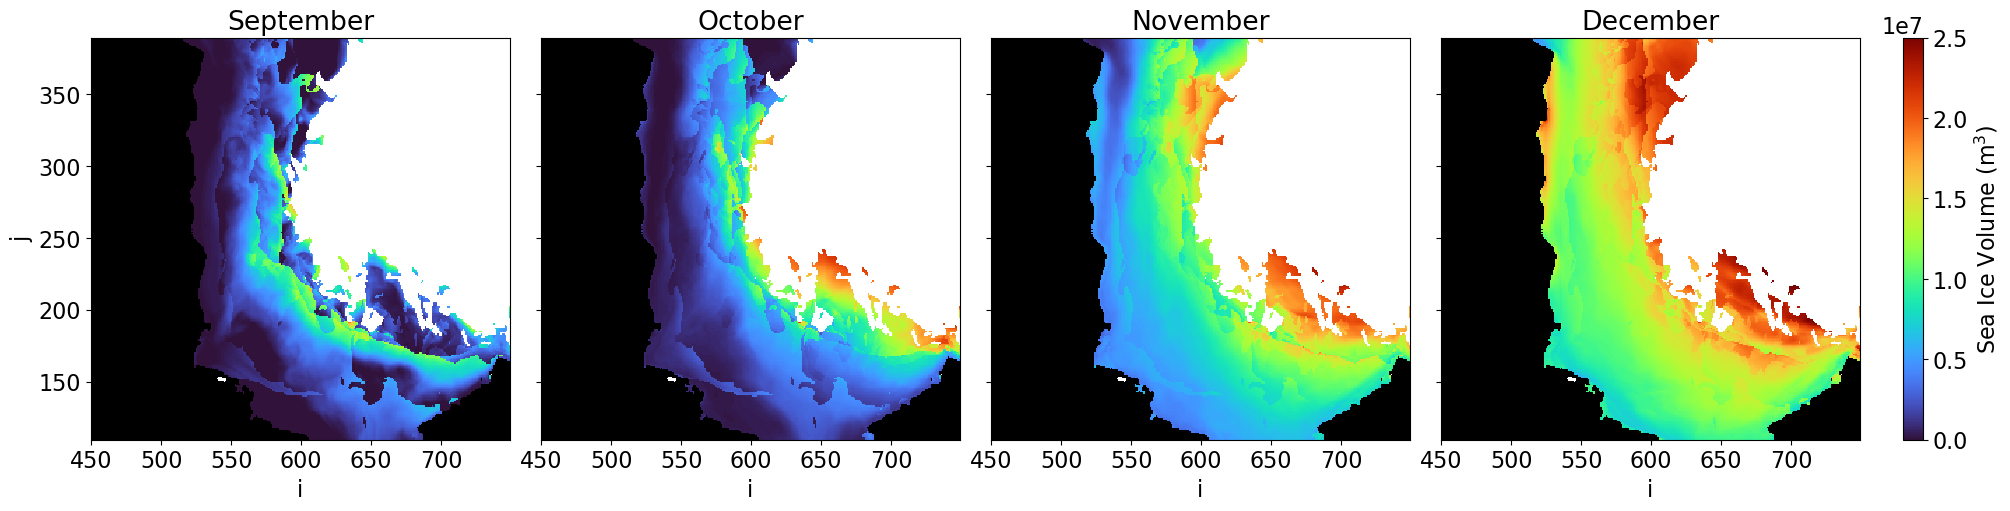

In [70]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, figsize=(20, 5), layout='constrained')


for i, (month, ax) in enumerate(zip(months, axes)):
    # plot land
    HH_grid_land.plot(ax=ax,vmin=0,vmax=1,cmap='grey',add_colorbar=False)
    # plot sea ice volume
    monthly_mean = ice_vol_yrs_masked.sel(time=fwc_binned_da['time.month'] == month).mean(dim='time')
    cbar_vol = monthly_mean.plot(ax=ax, vmin=0, vmax=2.5e7, cmap='turbo', add_colorbar=False)
    ax.set_title(month_names[i])
    ax.set_ylabel("")

axes[0].set_ylabel("j")

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_vol, ax=ax, orientation='vertical', pad=0.05)
cbar.ax.set_ylabel('Sea Ice Volume (m$^3$)')
# cbar.set_ticklabels(tick_labels)

plt.show()

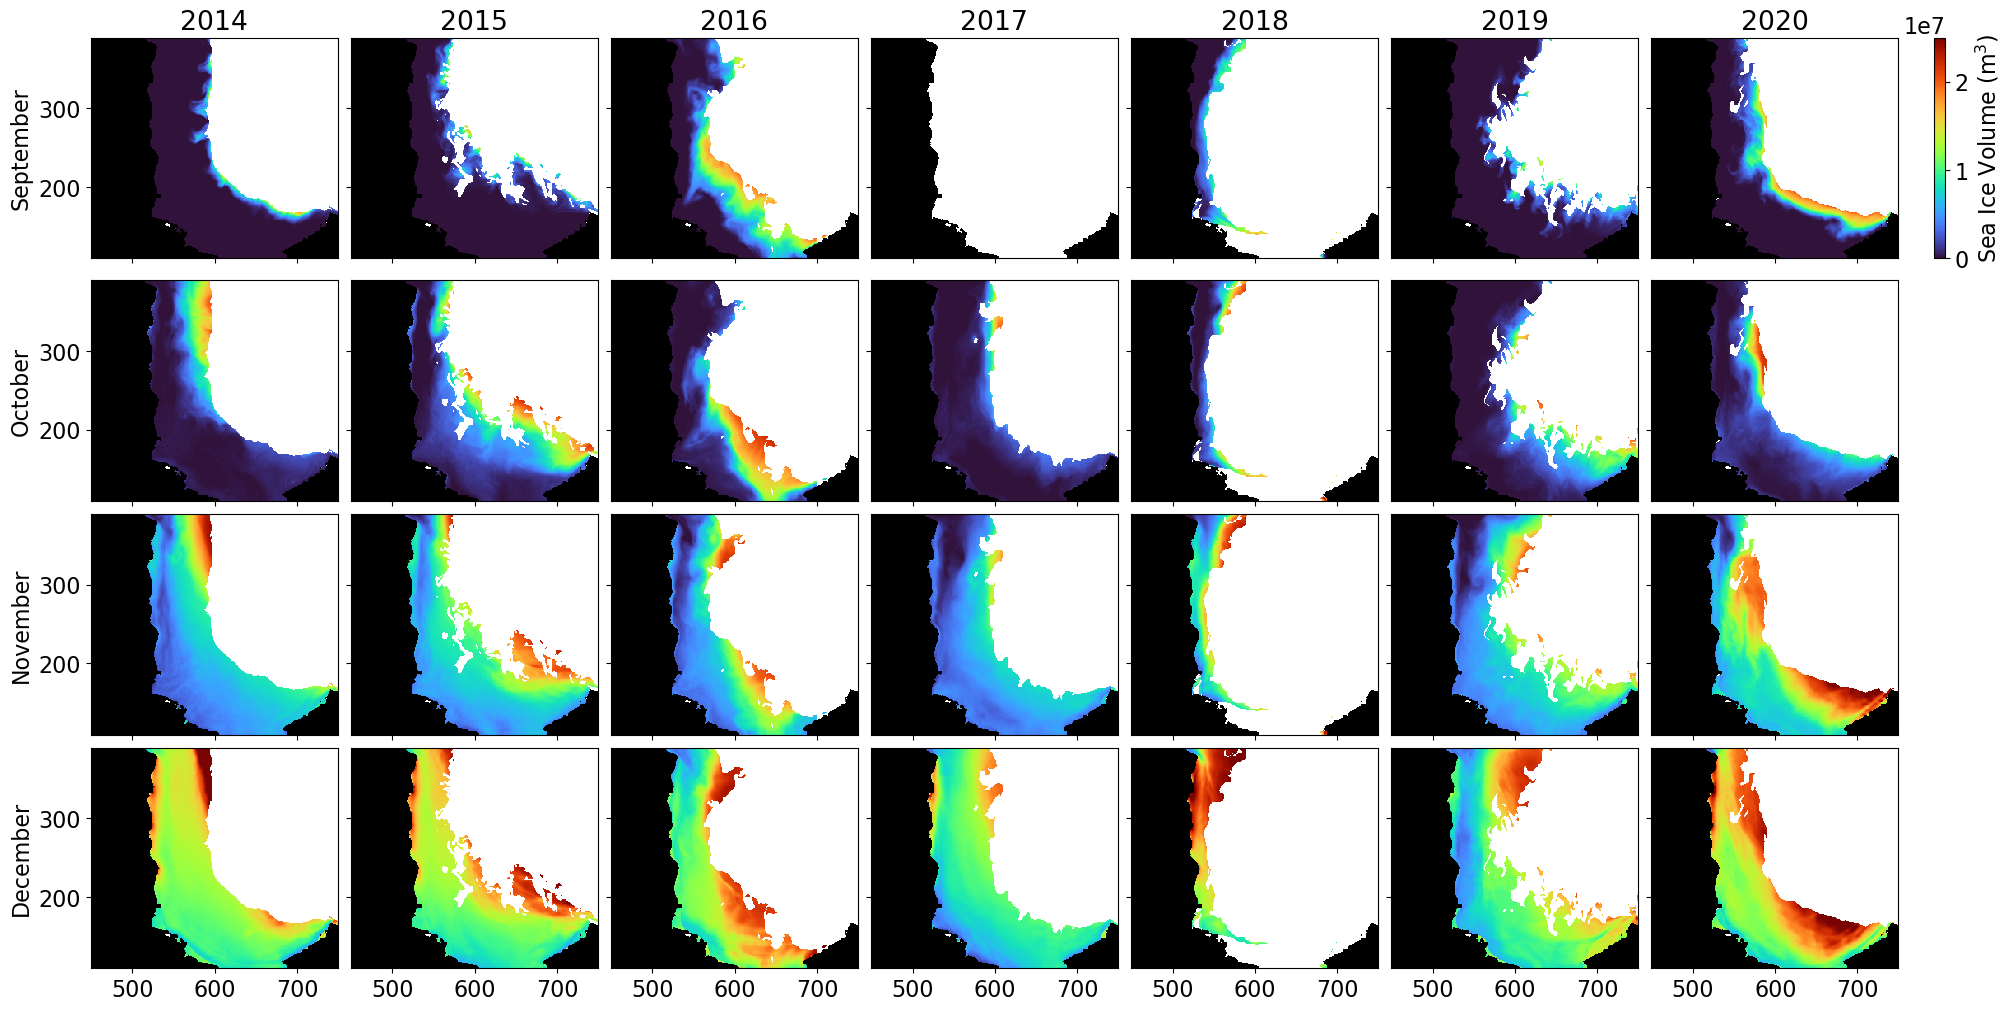

In [79]:
plt.rcParams['font.size'] = 16
months = [9, 10, 11, 12]
month_names = ['September', 'October', 'November', 'December']
years = list(range(2014, 2021))  # 2014–2020

fig, axes = plt.subplots(nrows=len(months), ncols=len(years), sharex=True, sharey=True, figsize=(20, 10), layout='constrained')

for month_idx, month in enumerate(months):
    for year_idx, year in enumerate(years):
        ax = axes[month_idx, year_idx]

        # Plot land
        HH_grid_land.plot(ax=ax, vmin=0, vmax=1, cmap='grey', add_colorbar=False)

        # Select data for specific year and month
        monthly_data = ice_vol_yrs_masked.sel(
            time=(ice_vol_yrs_masked['time.year'] == year) & 
                 (ice_vol_yrs_masked['time.month'] == month)
        ).mean(dim='time')

        # Plot sea ice volume
        plot_obj = monthly_data.plot(ax=ax, vmin=0, vmax=2.5e7, cmap='turbo', add_colorbar=False)

        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_title("")
        
        # Titles and labels
        if month_idx == 0:
            ax.set_title(str(year))
        if year_idx == 0:
            ax.set_ylabel(month_names[month_idx])

# Add a single colorbar to the right of all subplots
cbar = fig.colorbar(plot_obj, ax=axes[0, 6], orientation='vertical', pad=0.02)
cbar.ax.set_ylabel('Sea Ice Volume (m$^3$)')

plt.show()

## 3. Group by bins and calculate mean sea ice volume for each bin for every time step

In [28]:
# group by bins and calculate mean SIC
ice_vol_grouped_mean = ice_vol_yrs_masked.groupby(fwc_binned_da).mean(dim=['i','j'])

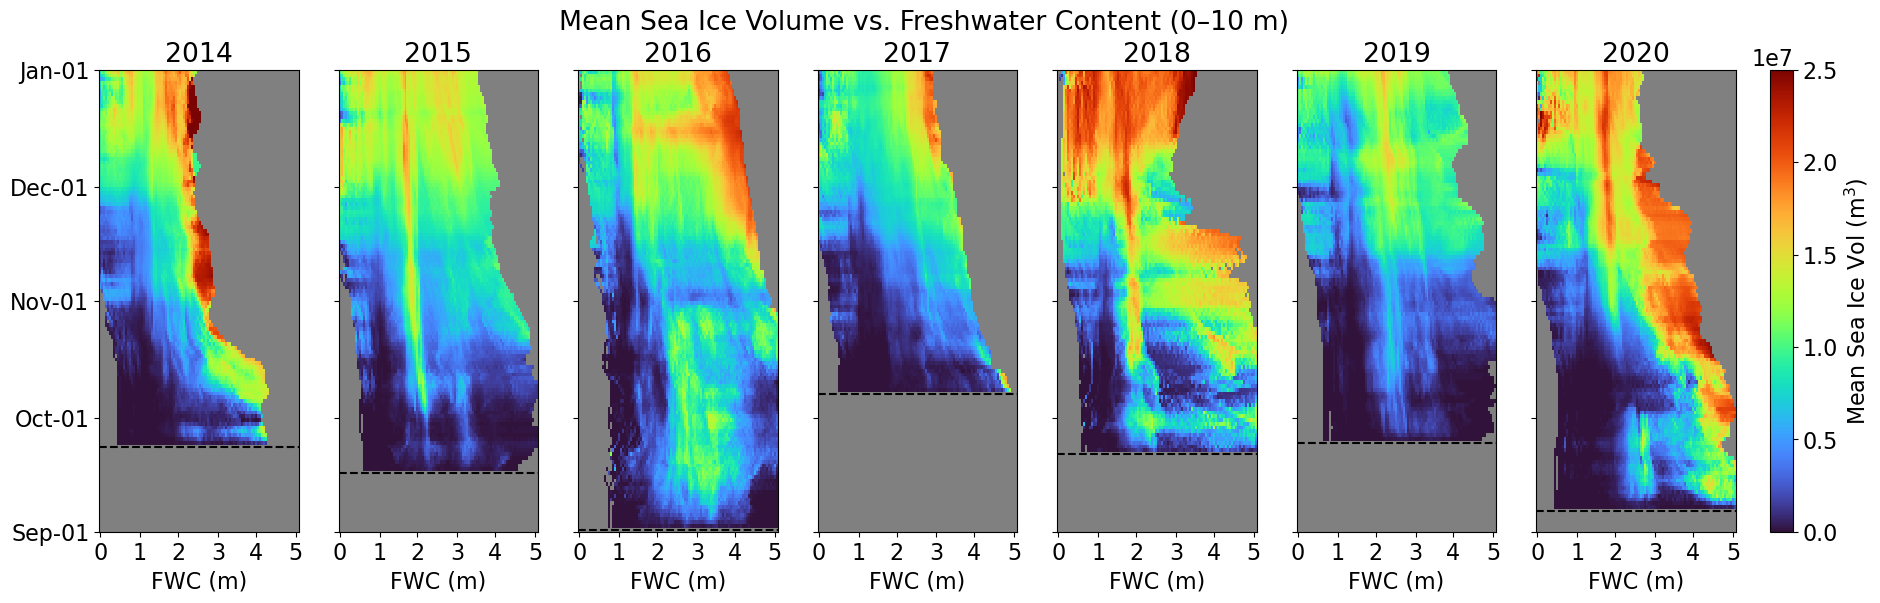

In [68]:
plt.rcParams['font.size'] = 16
fig, axs = plt.subplots(1, 7, sharex=True, figsize=[22, 6], gridspec_kw={'wspace': 0.2})
years = np.arange(2014, 2021)

for year, ax in zip(years, axs):
    # select one year at a time and remove first time step since all sea ice grid cells were masked for that date
    cbar_ice = ice_vol_grouped_mean.sel(time=str(year)).isel(time=slice(1, None)).plot(
        ax=ax,
        vmin=0, vmax=2.5e7,
        y='time',
        x='group',
        cmap='turbo',
        add_colorbar=False, extend='upper'
    )
    
    ax.set_facecolor('gray')
    ax.set_ylabel("")
    ax.set_title(str(year))
    ax.set_xlabel("FWC (m)")
    
    # Set y-axis limits and ticks
    ax.set_ylim(np.datetime64(f'{year}-09-01'), np.datetime64(f'{year+1}-01-01'))
    date_strings = [f'{year}-09-01', f'{year}-10-01', f'{year}-11-01',
                    f'{year}-12-01', f'{year+1}-01-01']
    dates = np.array(date_strings, dtype='datetime64[D]')
    ax.set_yticks(dates)
    ax.set_yticklabels("")

    # Set x-axis tick labels based on bins
    x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)),
                      np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)),
                      np.argmin(abs(fwc_bins - 5))]
    ax.set_xticks(x_tick_indices)
    ax.set_xticklabels(['0', '1', '2', '3', '4', '5'])

    # Add line for sea ice minimum
    ax.axhline(
        y=ice_vol_grouped_mean.sel(time=str(year)).isel(time=0).time.values,
        color='k',
        linewidth=1.5, linestyle='dashed'
    )

# Set y-tick labels only on the first subplot
axs[0].set_yticklabels(["Sep-01", "Oct-01", "Nov-01", "Dec-01", "Jan-01"])

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_ice, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.set_ylabel('Mean Sea Ice Vol (m$^3$)')

plt.suptitle("Mean Sea Ice Volume vs. Freshwater Content (0–10 m)")
plt.show()

contour colormap version

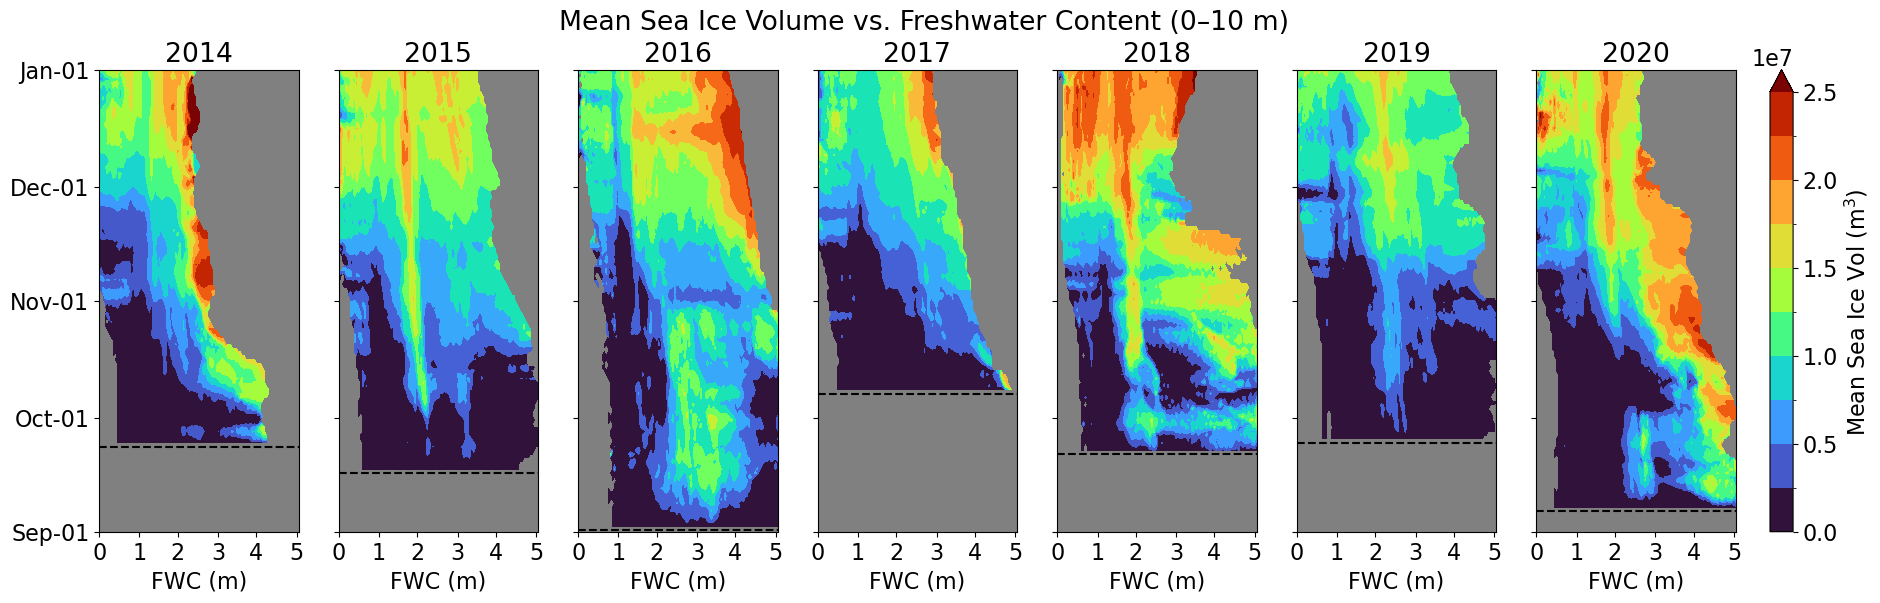

In [35]:
plt.rcParams['font.size'] = 16
fig, axs = plt.subplots(1, 7, sharex=True, figsize=[22, 6], gridspec_kw={'wspace': 0.2})
years = np.arange(2014, 2021)

levels=[0, 0.25e7, 0.5e7, 0.75e7, 1e7, 1.25e7, 1.5e7, 1.75e7, 2e7, 2.25e7, 2.5e7]

for year, ax in zip(years, axs):
    cbar_ice = ice_vol_grouped_mean.sel(time=str(year)).isel(time=slice(1, None)).plot.contourf(
        ax=ax,
        y='time',
        x='group',
        levels=levels,
        cmap='turbo',
        add_colorbar=False
    )
    
    ax.set_facecolor('gray')
    ax.set_ylabel("")
    ax.set_title(str(year))
    ax.set_xlabel("FWC (m)")
    
    # Set y-axis limits and ticks
    ax.set_ylim(np.datetime64(f'{year}-09-01'), np.datetime64(f'{year+1}-01-01'))
    date_strings = [f'{year}-09-01', f'{year}-10-01', f'{year}-11-01',
                    f'{year}-12-01', f'{year+1}-01-01']
    dates = np.array(date_strings, dtype='datetime64[D]')
    ax.set_yticks(dates)
    ax.set_yticklabels("")

    # Set x-axis tick labels based on bins
    x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)),
                      np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)),
                      np.argmin(abs(fwc_bins - 5))]
    ax.set_xticks(x_tick_indices)
    ax.set_xticklabels(['0', '1', '2', '3', '4', '5'])

    # Add line for sea ice minimum
    ax.axhline(
        y=ice_vol_grouped_mean.sel(time=str(year)).isel(time=0).time.values,
        color='k',
        linewidth=1.5, linestyle='dashed'
    )

# Set y-tick labels only on the first subplot
axs[0].set_yticklabels(["Sep-01", "Oct-01", "Nov-01", "Dec-01", "Jan-01"])

# Add colorbar to the last axis
cbar = fig.colorbar(cbar_ice, ax=axs, orientation='vertical', fraction=0.02, pad=0.02, ticks=[0, 0.5e7, 1e7, 1.5e7, 2e7, 2.5e7])
cbar.ax.set_ylabel('Mean Sea Ice Vol (m$^3$)')

plt.suptitle("Mean Sea Ice Volume vs. Freshwater Content (0–10 m)")
plt.show()

# Generate same plots over all years

In [36]:
from xarray.groupers import UniqueGrouper
from xarray.groupers import BinGrouper

In [37]:
# convert time to Day of Year (DOY)
doy = ice_vol_yrs_masked['time'].dt.dayofyear

# add bins and doy as coordinates
ice_vol_yrs_masked = ice_vol_yrs_masked.assign_coords(bins=fwc_binned_da).assign_coords(doy=doy)

In [38]:
# group by DOY and FWC bin, then compute the mean across years
groups = ice_vol_yrs_masked.groupby(bins=UniqueGrouper(),doy=UniqueGrouper())
# groups = ice_yrs_masked.groupby('time.dayofyear')

In [39]:
# check groups
groups

<DataArrayGroupBy, grouped over 2 grouper(s), 12200 groups in total:
    'bins': 100/100 groups present with labels 0.0, 1.0, 2.0, ..., 97.0, 98.0, 99.0
    'doy': 122/122 groups present with labels 245, 246, 247, ..., 364, 365, 366>

In [40]:
# then reduce by taking mean
ice_vol_yrs_masked_mean = groups.mean()

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/flox/core.py:2368: PerformanceWarning: Slicing with an out-of-order index is generating 90 times more chunks
  result = result[..., sorted_idx]


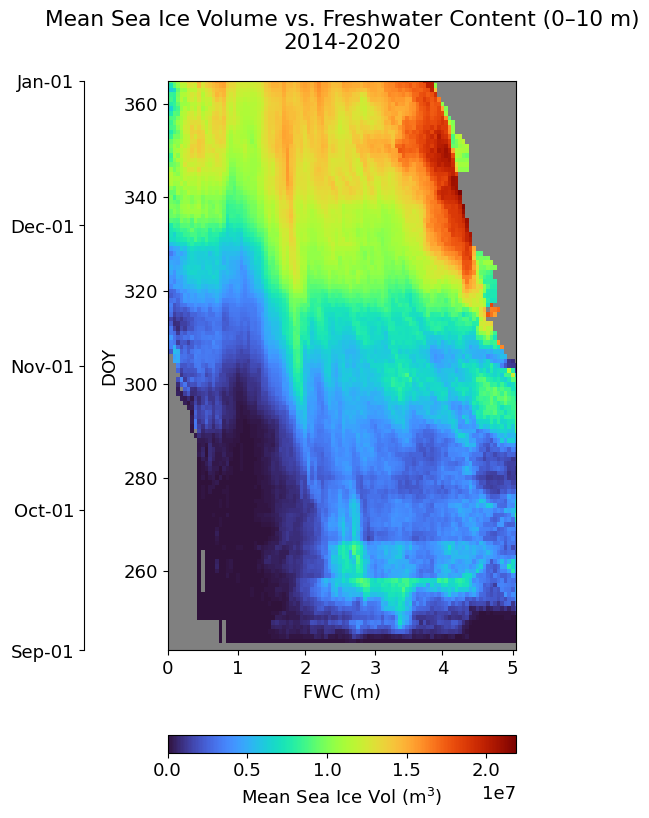

In [43]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(4.5, 10))

# Plot Hovmöller Diagram
cbar_plot = ice_vol_yrs_masked_mean.plot(
    ax=ax, x='bins', y='doy', cmap='turbo', add_colorbar=False
)
ax.set_facecolor('gray')

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 334, 365]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('Mean Sea Ice Volume vs. Freshwater Content (0–10 m)\n2014-2020\n')
ax.set_xlabel("FWC (m)")
ax.set_ylabel('DOY')
ax.set_xlim(0, 99)
ax.set_ylim(243, 365)

# Set x-axis tick labels based on bins
x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)),
                  np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)),
                  np.argmin(abs(fwc_bins - 5))]
ax.set_xticks(x_tick_indices)
ax.set_xticklabels(['0', '1', '2', '3', '4', '5'])

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.11)
cbar.set_label("Mean Sea Ice Vol (m$^3$)")

plt.show()

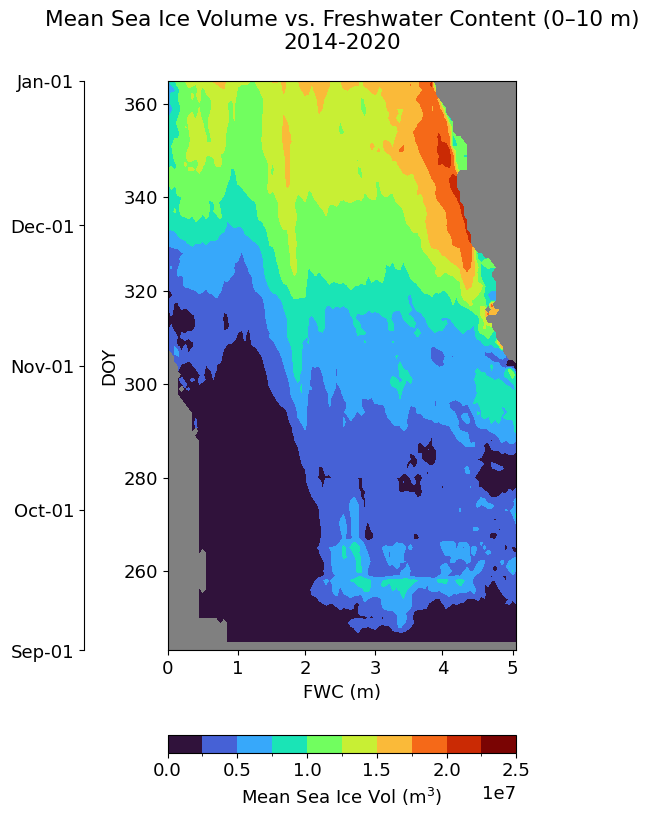

In [44]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(4.5, 10))

# Define contour levels
levels=[0, 0.25e7, 0.5e7, 0.75e7, 1e7, 1.25e7, 1.5e7, 1.75e7, 2e7, 2.25e7, 2.5e7]

# Plot Hovmöller Diagram
cbar_plot = ice_vol_yrs_masked_mean.plot.contourf(
    ax=ax, x='bins', y='doy', cmap='turbo', levels=levels, add_colorbar=False
)
ax.set_facecolor('gray')

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 334, 365]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('Mean Sea Ice Volume vs. Freshwater Content (0–10 m)\n2014-2020\n')
ax.set_xlabel("FWC (m)")
ax.set_ylabel('DOY')
ax.set_xlim(0, 99)
ax.set_ylim(243, 365)

# Set x-axis tick labels based on bins
x_tick_indices = [0, np.argmin(abs(fwc_bins - 1)), np.argmin(abs(fwc_bins - 2)),
                  np.argmin(abs(fwc_bins - 3)), np.argmin(abs(fwc_bins - 4)),
                  np.argmin(abs(fwc_bins - 5))]
ax.set_xticks(x_tick_indices)
ax.set_xticklabels(['0', '1', '2', '3', '4', '5'])

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.11, ticks=[0, 0.5e7, 1e7, 1.5e7, 2e7, 2.5e7])
cbar.set_label("Mean Sea Ice Vol (m$^3$)")

plt.show()